In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ============================================================
# SSH: common utilities, energy band plots, and occupation overlays
# ============================================================

def ssh_couplings(lam: float) -> tuple[float, float]:
    """t1 = 1 - lam,  t2 = 1 + lam"""
    return 1.0 - lam, 1.0 + lam

def ssh_dispersion_from_t1t2(k: np.ndarray, t1, t2) -> np.ndarray:
    """|h(k)| = sqrt(t1^2 + t2^2 + 2 t1 t2 cos k)"""
    return np.sqrt(t1**2 + t2**2 + 2.0*t1*t2*np.cos(k))

def ssh_energy_pm(k: np.ndarray, lam: float) -> tuple[np.ndarray, np.ndarray]:
    """E_-(k), E_+(k) using lam parametrization."""
    t1, t2 = ssh_couplings(lam)
    Ep = ssh_dispersion_from_t1t2(k, t1, t2)
    return -Ep, Ep

def make_figure_ssh_bands(
    lams_line=(-0.8, -0.4, 0.0, 0.4, 0.8),
    lam_range=(-1.0, 1.0),
    nk=400,
    nlam=400,
    cmap="inferno",
    savepath=None,
    show=True,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_1_ssh_bands.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk)
    lam_grid = np.linspace(lam_range[0], lam_range[1], nlam)
    K, L = np.meshgrid(k, lam_grid)

    t1 = 1.0 - L
    t2 = 1.0 + L
    E2D = ssh_dispersion_from_t1t2(K, t1, t2)

    fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

    # Panel A
    ax1 = axes[0]
    for lam in lams_line:
        Em, Ep = ssh_energy_pm(k, lam)
        (line,) = ax1.plot(k, Ep, label=rf"$\lambda={lam}$")
        ax1.plot(k, Em, color=line.get_color())

    ax1.set_xlabel(r"$k$")
    ax1.set_ylabel("Energy")
    ax1.set_title(r"SSH band structure for different $\lambda$")
    ax1.legend()

    xticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

    # Panel B
    ax2 = axes[1]
    pcm = ax2.pcolormesh(K, L, E2D, shading="auto", cmap=cmap)
    ax2.set_xlabel(r"$k$")
    ax2.set_ylabel(r"$\lambda$")
    ax2.set_title(r"Upper SSH energy band $E_+(k,\lambda)$")
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    fig.colorbar(pcm, ax=ax2, label="Energy")

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axes

def fermi_dirac(E: np.ndarray, beta: float) -> np.ndarray:
    """Fermi–Dirac distribution: n(E) = 1/(exp(beta E)+1)."""
    return 1.0 / (np.exp(beta * E) + 1.0)

def make_figure_upper_occupation_overlay(
    lam: float = 0.0,
    betas=(30, 5, 2, 1, 0.5),
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    """
    Single-panel overlay of n_+(k) for multiple betas at fixed lambda.
    Uses n_+(k) = 1/(exp(beta E_+(k))+1), with E_+(k)=|h(k)|.
    """
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_occ_overlay_lam{lam}.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk, endpoint=False)

    t1, t2 = ssh_couplings(lam)
    E_plus = ssh_dispersion_from_t1t2(k, t1, t2)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.8))

    for beta in betas:
        n_plus = fermi_dirac(E_plus, beta)
        ax.plot(k, n_plus, label=rf"$\beta={beta}$")

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$n_+(k)$")
    ax.set_title(rf"Upper band occupation $n_+(k)$ (fixed $\lambda={lam}$)")

    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_ylim(-0.02, 0.52)  # çünkü n_+ ∈ [0, 1/2] (mu=0 simetri)

    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def make_figure_upper_occupation_overlay_lams(
    beta: float = 2.0,
    lams=(0.0, 0.1, 0.4, 0.8),
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_occ_overlay_beta{beta}.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk, endpoint=False)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.8))

    for lam in lams:
        t1, t2 = ssh_couplings(lam)
        E_plus = ssh_dispersion_from_t1t2(k, t1, t2)
        n_plus = fermi_dirac(E_plus, beta)
        ax.plot(k, n_plus, label=rf"$\lambda={lam}$")

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$n_+(k)$")
    ax.set_title(rf"Upper band occupation $n_+(k)$ (fixed $\beta={beta}$)")

    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_ylim(-0.02, 0.52)

    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

# ============================================================
# Concurrence (continuum, Kim&Cho-style) utilities
# ============================================================

# k-grid for continuum integrals (periodic grid; endpoint=False önemli)
KS = np.linspace(0, 2*np.pi, 8192, endpoint=False)

def k_grid_finiteN(N: int, bz: str = "0_2pi") -> np.ndarray:
    """
    Discrete k grid for a periodic chain of length N:
      k_n = 2π n / N , n=0,...,N-1

    bz="0_2pi" -> [0,2π)
    bz="pm_pi" -> [-π,π)
    """
    if bz == "0_2pi":
        return np.linspace(0.0, 2.0*np.pi, N, endpoint=False)
    elif bz == "pm_pi":
        return np.linspace(-np.pi, np.pi, N, endpoint=False)
    else:
        raise ValueError("bz must be '0_2pi' or 'pm_pi'")
    
def h_complex_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    """
    Bloch off-diagonal term: h(k) = t1 + t2 e^{-ik}.
    Uses our convention t1=1-lam, t2=1+lam (via ssh_couplings).
    """
    t1, t2 = ssh_couplings(lam)
    return t1 + t2 * np.exp(-1j * k)

def abs_h_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    return np.abs(h_complex_from_lam(lam, k))

def phi_k_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    # phase in (-0, 2pi]
    return np.angle(h_complex_from_lam(lam, k))

def eta_continuum(lam: float, beta=np.inf, r: int = 0, ks: np.ndarray = KS) -> float:
    """
    Continuum correlator amplitude:
      η_r(λ,β) = (1/2π) ∫ dk  tanh(β|h(k)|/2) cos(rk + φ(k))
        where r=m-n is the site separation, and φ(k) = arg(h(k)).
    beta = np.inf -> tanh(...) -> 1 (ground-state limit)
    """
    ph = phi_k_from_lam(lam, ks)
    if np.isinf(beta):
        w = 1.0
        return np.cos(r*ks + ph).mean()
    else:
        w = np.tanh(0.5 * beta * abs_h_from_lam(lam, ks))
        return (w * np.cos(r*ks + ph)).mean()

def eta_finiteN(lam: float, N: int, beta=np.inf, r: int = 0, bz: str = "0_2pi") -> float:
    """
    Finite-N correlator amplitude:
      η_r(λ,β;N) = (1/N) Σ_k  tanh(β|h(k)|/2) cos(rk + φ(k))

    beta=np.inf -> tanh -> 1 (T=0 limit)
    """
    ks = k_grid_finiteN(N, bz=bz)
    ph = phi_k_from_lam(lam, ks)

    if np.isinf(beta):
        return np.cos(r*ks + ph).mean()
    else:
        w = np.tanh(0.5 * beta * abs_h_from_lam(lam, ks))
        return (w * np.cos(r*ks + ph)).mean()
    
def concurrence_from_eta(eta: float) -> float:
    """
    For the X-state structure used in the report:
      C = max(0, 1/2 (eta^2 + 2|eta| - 1))
    This matches the Kim&Cho active branch at T=0 (eta>=0),
    and stays safe if eta changes sign.
    """
    return max(0.0, 0.5 * (eta**2 + 2.0*np.abs(eta) - 1.0))

def _crossing_at_boundary(x: np.ndarray, y: np.ndarray, j: int, eps: float):
    """
    Linear interpolation for crossing y=eps between indices j-1 and j.
    Assumes y[j-1] and y[j] are on different sides of eps.
    """
    x0, x1 = x[j-1], x[j]
    y0, y1 = y[j-1], y[j]
    if np.isclose(y1, y0):
        return x1
    return x0 + (eps - y0) * (x1 - x0) / (y1 - y0)

def nonzero_region_boundaries(
    x: np.ndarray, y: np.ndarray, eps: float = 1e-10
):
    """
    Finds the left and right boundary of the region where y > eps.
    Returns (x_left, x_right). If y never exceeds eps -> (None, None).

    Works for:
      - "turn-on" (0 -> >0) on the right side
      - "turn-off" (>0 -> 0) on the right side
      - any single contiguous nonzero region (which is our case)
    """
    mask = y > eps
    if not np.any(mask):
        return None, None

    idx = np.where(mask)[0]
    i_left = idx[0]
    i_right = idx[-1]

    # left boundary
    if i_left == 0:
        x_left = x[0]
    else:
        x_left = _crossing_at_boundary(x, y, i_left, eps)

    # right boundary
    if i_right == len(x) - 1:
        x_right = x[-1]
    else:
        x_right = _crossing_at_boundary(x, y, i_right + 1, eps)

    return x_left, x_right

def make_figure_concurrence_vs_lambda(
    lam_min=-1.0,
    lam_max=1.0,
    num=2001,
    beta=np.inf,
    ks=KS,
    savepath=None,
    show=True,
    title=None,
    mark_lambda0=True,
):
    """
    Kim & Cho Fig.2 style plot of concurrence vs lambda, with:
      - C1(λ)  (r=0)
      - C2(λ)  (r=1)
      - dC2/dλ (right axis)
    beta=np.inf -> ground-state limit
    beta finite  -> thermal
    """

    if savepath is None:
        tag = "T0" if np.isinf(beta) else f"beta{beta:g}"
        savepath = f"{FIG_DIR}/fig_concurrence_{tag}.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    # compute eta and concurrence
    eta0 = np.array([eta_continuum(l, beta=beta, r=0, ks=ks) for l in lams])
    eta1 = np.array([eta_continuum(l, beta=beta, r=1, ks=ks) for l in lams])

    C1 = np.array([concurrence_from_eta(x) for x in eta0])
    C2 = np.array([concurrence_from_eta(x) for x in eta1])

    # derivative (clean + robust)
    dC2 = np.gradient(C2, lams)

    # ---- plot
    fig, axC = plt.subplots(figsize=(7.2, 4.6))
    axD = axC.twinx()

    ln1, = axC.plot(lams, C1, color="mediumorchid", lw=2, label=r"$C_1(\lambda)$")
    ln2, = axC.plot(lams, C2, color="seagreen",    lw=2, label=r"$C_2(\lambda)$")
    ln3, = axD.plot(lams, dC2, color="deepskyblue", lw=2, label=r"$\partial_\lambda C_2$")

    if mark_lambda0:
        axC.axvline(0.0, ls="--", lw=1)

    axC.set_xlabel(r"$\lambda$")
    axC.set_ylabel("Concurrence")
    axD.set_ylabel(r"$\partial_\lambda C_2$")

    tag = "T=0" if np.isinf(beta) else rf"$\beta={beta:g}$"
    axC.set_title(title or rf"Wootters concurrence ({tag})")

    # combined legend
    lines = [ln1, ln2, ln3]
    axC.legend(lines, [l.get_label() for l in lines], frameon=False, loc="upper left")

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    eps = 1e-10  

    c1_left, c1_right = nonzero_region_boundaries(lams, C1, eps=eps)
    c2_left, c2_right = nonzero_region_boundaries(lams, C2, eps=eps)

    # critical lambda values:
    lamc1 = c1_right
    lamc2 = c2_left
    print(f"[{tag}] lambda_c1 (C1 -> 0) ~ {lamc1}")
    print(f"[{tag}] lambda_c2 (C2 turns on) ~ {lamc2}")

    if lamc1 is not None:
        axC.axvline(lamc1, ls="--", color="gray", lw=1)
    if lamc2 is not None:
        axC.axvline(lamc2, ls="--", color="gray", lw=1)

    return fig, (axC, axD)

def make_figure_C1_overlay_betas(
    betas=(np.inf, 30, 10, 5, 2, 1),
    lam_min=-1.0,
    lam_max=1.0,
    num=2001,
    ks=KS,
    eps=1e-10,
    savepath=None,
    show=True,
    title=None,
):
    """
    Overlay plot of C1(λ) for multiple beta values on a single axis.
    Includes printed critical lambda where C1 drops to ~0 (right boundary).
    """
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_C1_overlay_betas.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for beta in betas:
        eta0 = np.array([eta_continuum(l, beta=beta, r=0, ks=ks) for l in lams])
        C1 = np.array([concurrence_from_eta(x) for x in eta0])

        # critical lambda (where C1 goes to ~0): use nonzero region right boundary
        c1_left, c1_right = nonzero_region_boundaries(lams, C1, eps=eps)
        tag = "∞" if np.isinf(beta) else f"{beta:g}"
        print(f"[C1 overlay] beta={tag:>3}  lambda_c1 (C1->0) ~ {c1_right}")

        ax.plot(lams, C1, lw=2, label=rf"$\beta={tag}$")

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$C_1(\lambda)$")
    ax.set_xlim(lam_min, lam_max)

    ax.set_title(title or r"$C_1(\lambda)$ for different temperatures")
    ax.legend(frameon=False, ncol=2)

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def make_figure_concurrence_finiteN(
    lam_lo=-0.05,
    lam_hi=0.05,
    num=1201,
    Ns=(50, 51),
    beta=np.inf,
    r=1,
    bz="0_2pi",
    savepath=None,
    show=True,
    title=None,
):
    """
    Plot C_r(λ) for several finite N values.
    r=0 -> C1-like, r=1 -> C2-like (depending on your mapping).
    """
    if savepath is None:
        tag = "T0" if np.isinf(beta) else f"beta{beta:g}"
        savepath = f"{FIG_DIR}/fig_finiteN_Cr_r{r}_{tag}.pdf"

    lams = np.linspace(lam_lo, lam_hi, num)
    fig, ax = plt.subplots(figsize=(7.0, 4.2))

    for N in Ns:
        eta = np.array([eta_finiteN(l, N=N, beta=beta, r=r, bz=bz) for l in lams])
        C = np.array([concurrence_from_eta(x) for x in eta])
        tagN = "T=0" if np.isinf(beta) else rf"$\beta={beta:g}$"
        ax.plot(lams, C, lw=2, label=rf"$N={N}$ ({tagN})")

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(rf"$C_{r}(\lambda)$")
    ax.set_title(title or "Finite-$N$ concurrence")
    ax.legend(frameon=False)

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def lambda_critical_for_beta(beta, lams, r, ks=KS, eps=1e-10):
    """
    For fixed beta, scan lambda grid and return the critical lambda boundary.
    r=0 -> C1: take RIGHT boundary (where C1 -> 0)
    r=1 -> C2: take LEFT boundary  (where C2 turns on)
    """
    eta = np.array([eta_continuum(l, beta=beta, r=r, ks=ks) for l in lams])
    C   = np.array([concurrence_from_eta(x) for x in eta])
    left, right = nonzero_region_boundaries(lams, C, eps=eps)
    return right if r == 0 else left

def make_figure_lambda_critical_vs_beta(
    betas=None,
    lam_min=-0.30,
    lam_max=0.30,
    nlam=400,
    eps=1e-10,
    ks=KS,
    savepath=None,
    show=True,
    # NEW:
    print_values=True,
    save_csv_path=None,   # e.g. f"{FIG_DIR}/lambda_critical_vs_beta.csv"
):
    if betas is None:
        betas = np.r_[np.geomspace(0.2, 30.0, 100), np.inf]

    lams = np.linspace(lam_min, lam_max, nlam)

    lamc1 = []
    lamc2 = []
    for beta in betas:
        lamc1.append(lambda_critical_for_beta(beta, lams, r=0, ks=ks, eps=eps))
        lamc2.append(lambda_critical_for_beta(beta, lams, r=1, ks=ks, eps=eps))

    lamc1 = np.array(lamc1, dtype=float)
    lamc2 = np.array(lamc2, dtype=float)

    # ---- PRINT TABLE (NEW)
    if print_values:
        print("\nCritical lambdas from concurrence boundary detection")
        print(f"eps = {eps:g}, ks = {ks}, lambda-grid = [{lam_min}, {lam_max}] with nlam={nlam}")
        print("--------------------------------------------------------------")
        print(f"{'beta':>10}   {'lambda_c1 (C1->0)':>18}   {'lambda_c2 (C2 on)':>18}")
        for b, c1, c2 in zip(betas, lamc1, lamc2):
            bstr = "inf" if np.isinf(b) else f"{b:10.6g}"
            c1str = "None" if np.isnan(c1) else f"{c1:18.10f}"
            c2str = "None" if np.isnan(c2) else f"{c2:18.10f}"
            print(f"{bstr:>10}   {c1str}   {c2str}")

    # ---- SAVE CSV (NEW)
    if save_csv_path is not None:
        beta_out = np.array(betas, dtype=float)
        header = "beta,lambda_c1,lambda_c2"
        data = np.column_stack([beta_out, lamc1, lamc2])
        np.savetxt(save_csv_path, data, delimiter=",", header=header, comments="")
        if print_values:
            print("\nSaved CSV to:", save_csv_path)

    # x-axis: finite betas for log plot
    finite = np.isfinite(betas)
    betas_f = np.array(betas)[finite]
    lamc1_f = lamc1[finite]
    lamc2_f = lamc2[finite]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(betas_f, lamc1_f, lw=2, label=r"$\lambda_{c1}(\beta)$  (C1$\to$0)")
    ax.plot(betas_f, lamc2_f, lw=2, label=r"$\lambda_{c2}(\beta)$  (C2 turns on)")

    # mark T=0 point (beta=inf) as a dot at the right edge
    if np.any(~finite):
        ax.scatter([betas_f.max()], [lamc1[~finite][0]], s=35)
        ax.scatter([betas_f.max()], [lamc2[~finite][0]], s=35)

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda_c$")
    ax.set_title(r"Critical $\lambda_c(\beta)$ from concurrence")
    ax.legend(frameon=False)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax, (betas, lamc1, lamc2)

In [ ]:
#Energy band diagrams for the SSH model
#(a)Upper energy band E+(k) for selected lambdas
#(b)Upper energy band E+(k, lambda) heatmap
make_figure_ssh_bands()

In [ ]:
make_figure_upper_occupation_overlay(lam=0.0, betas=(30, 5, 2, 1, 0.5))

In [ ]:
make_figure_upper_occupation_overlay_lams(beta=5.0, lams=(0.0, 0.138, 0.4, 0.8))

In [ ]:
make_figure_concurrence_vs_lambda(beta=np.inf)
make_figure_concurrence_vs_lambda(beta=30)
make_figure_concurrence_vs_lambda(beta=2)

In [ ]:
make_figure_C1_overlay_betas(betas=(np.inf, 30, 10, 5, 2,1.5,1,0.5))

In [ ]:
make_figure_concurrence_finiteN(
    lam_lo=-0.02, lam_hi=0.02,
    Ns=(50, 51),
    beta=np.inf,
    r=1
)

In [ ]:
make_figure_concurrence_finiteN(
    lam_lo=-0.01, lam_hi=0.01,
    Ns=(50, 60,70),
    beta=np.inf,
    r=1
)


Critical lambdas from concurrence boundary detection
eps = 1e-10, ks = [0.00000000e+00 7.66990394e-04 1.53398079e-03 ... 6.28088434e+00
 6.28165133e+00 6.28241832e+00], lambda-grid = [-0.3, 0.3] with nlam=400
--------------------------------------------------------------
      beta    lambda_c1 (C1->0)    lambda_c2 (C2 on)
       0.2   None   None
  0.210383   None   None
  0.221305   None   None
  0.232794   None   None
   0.24488   None   None
  0.257593   None   None
  0.270966   None   None
  0.285033   None   None
   0.29983   None   None
  0.315396   None   None
   0.33177   None   None
  0.348994   None   None
  0.367112   None   None
  0.386171   None   None
  0.406219   None   None
  0.427308   None   None
  0.449492   None   None
  0.472827   None   None
  0.497374   None   None
  0.523195   None   None
  0.550357   None   None
  0.578929   None   None
  0.608984   None   None
  0.640599   None   None
  0.673856   None   None
   0.70884        -0.2924812038         0.2924812

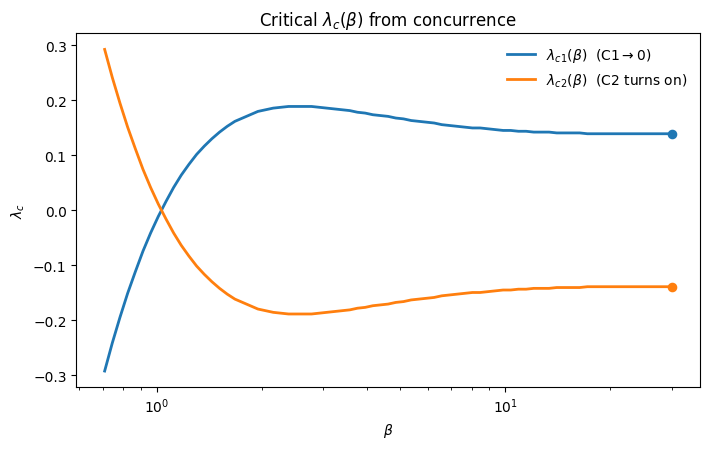

In [38]:
fig, ax, (betas, lamc1, lamc2) = make_figure_lambda_critical_vs_beta(
    eps=1e-10,
    ks=KS,
    savepath=f"{FIG_DIR}/fig_lambda_critical_vs_beta.pdf",
    save_csv_path=f"{FIG_DIR}/lambda_critical_vs_beta.csv",
    print_values=True,
    show=True,
)

In [ ]:
import numpy as np

def _compute_C1_C2_and_lamc(
    beta,
    lam_min=-0.30,
    lam_max=0.30,
    num=4001,
    ks=KS,
    eps=1e-10,
):
    lams = np.linspace(lam_min, lam_max, num)

    eta0 = np.array([eta_continuum(l, beta=beta, r=0, ks=ks) for l in lams])
    eta1 = np.array([eta_continuum(l, beta=beta, r=1, ks=ks) for l in lams])

    C1 = np.array([concurrence_from_eta(x) for x in eta0])
    C2 = np.array([concurrence_from_eta(x) for x in eta1])

    c1_left, c1_right = nonzero_region_boundaries(lams, C1, eps=eps)
    c2_left, c2_right = nonzero_region_boundaries(lams, C2, eps=eps)

    lamc1 = c1_right          # C1 -> 0 (right boundary)
    lamc2 = c2_left           # C2 turns on (left boundary)

    return lams, C1, C2, lamc1, lamc2


def run_numerical_sanity_tests(
    betas=(np.inf, 30.0, 10.0, 2.0),
    lam_window=(-1, 1),
    ks_list=(4096, 8192, 16384),
    num_list=(2001, 4001, 8001),
    eps_list=(1e-6, 1e-8, 1e-10),
    # PASS/FAIL thresholds (tweakable)
    lamc_tol_ks=2e-3,     # how much lamc is allowed to move when ks increases
    lamc_tol_num=2e-3,    # how much lamc is allowed to move when num increases
    lamc_tol_eps_highT=2e-2,  # low beta is allowed to be more sensitive
    lamc_tol_eps_lowT=2e-3,   # high beta should be stable under eps
):
    lam_min, lam_max = lam_window

    print("\n==============================")
    print(" NUMERICAL SANITY TEST REPORT ")
    print("==============================")
    print(f"lambda window: [{lam_min}, {lam_max}]")
    print(f"ks_list: {ks_list}")
    print(f"num_list: {num_list}")
    print(f"eps_list: {eps_list}")
    print("")

    overall_ok = True

    for beta in betas:
        tag = "inf" if np.isinf(beta) else f"{beta:g}"
        print("------------------------------------------------------------")
        print(f"beta = {tag}")
        print("------------------------------------------------------------")

        # Choose "baseline" settings
        ks0 = ks_list[0]
        num0 = num_list[0]
        eps0 = eps_list[-1]  # usually smallest eps as baseline (1e-10)

        # Baseline compute
        l0, C1_0, C2_0, lamc1_0, lamc2_0 = _compute_C1_C2_and_lamc(
            beta=beta, lam_min=lam_min, lam_max=lam_max, num=num0, ks=ks0, eps=eps0
        )

        print(f"Baseline (ks={ks0}, num={num0}, eps={eps0:g}):")
        print(f"  lamc1 ~ {lamc1_0}")
        print(f"  lamc2 ~ {lamc2_0}")

        # ---------- (A) ks convergence
        print("\n(A) ks convergence (fix num, eps):")
        lamc1_vals = []
        lamc2_vals = []
        for ks in ks_list:
            _, _, _, lc1, lc2 = _compute_C1_C2_and_lamc(
                beta=beta, lam_min=lam_min, lam_max=lam_max, num=num0, ks=ks, eps=eps0
            )
            lamc1_vals.append(lc1)
            lamc2_vals.append(lc2)
            print(f"  ks={ks:>6}: lamc1={lc1}, lamc2={lc2}")

        # measure drift (ignore None/nan robustly)
        def _finite_drift(vals):
            vv = np.array(vals, dtype=float)
            vv = vv[np.isfinite(vv)]
            if len(vv) <= 1:
                return 0.0
            return float(np.nanmax(vv) - np.nanmin(vv))

        drift_ks_c1 = _finite_drift(lamc1_vals)
        drift_ks_c2 = _finite_drift(lamc2_vals)
        print(f"  drift_ks: C1={drift_ks_c1:.3e}, C2={drift_ks_c2:.3e}")

        if drift_ks_c1 > lamc_tol_ks or drift_ks_c2 > lamc_tol_ks:
            overall_ok = False
            print("  ⚠️ ks drift is larger than tolerance → may need larger ks.")

        # ---------- (B) num convergence
        print("\n(B) lambda-grid (num) convergence (fix ks, eps):")
        lamc1_vals = []
        lamc2_vals = []
        for num in num_list:
            _, _, _, lc1, lc2 = _compute_C1_C2_and_lamc(
                beta=beta, lam_min=lam_min, lam_max=lam_max, num=num, ks=ks0, eps=eps0
            )
            lamc1_vals.append(lc1)
            lamc2_vals.append(lc2)
            dlam = (lam_max - lam_min) / (num - 1)
            print(f"  num={num:>5} (Δλ≈{dlam:.2e}): lamc1={lc1}, lamc2={lc2}")

        drift_num_c1 = _finite_drift(lamc1_vals)
        drift_num_c2 = _finite_drift(lamc2_vals)
        print(f"  drift_num: C1={drift_num_c1:.3e}, C2={drift_num_c2:.3e}")

        if drift_num_c1 > lamc_tol_num or drift_num_c2 > lamc_tol_num:
            overall_ok = False
            print("  ⚠️ num drift is larger than tolerance → increase num near boundary.")

        # ---------- (C) eps sensitivity
        print("\n(C) eps sensitivity (fix ks, num):")
        lamc1_vals = []
        lamc2_vals = []
        for eps in eps_list:
            _, _, _, lc1, lc2 = _compute_C1_C2_and_lamc(
                beta=beta, lam_min=lam_min, lam_max=lam_max, num=num0, ks=ks0, eps=eps
            )
            lamc1_vals.append(lc1)
            lamc2_vals.append(lc2)
            print(f"  eps={eps:>8g}: lamc1={lc1}, lamc2={lc2}")

        drift_eps_c1 = _finite_drift(lamc1_vals)
        drift_eps_c2 = _finite_drift(lamc2_vals)
        print(f"  drift_eps: C1={drift_eps_c1:.3e}, C2={drift_eps_c2:.3e}")

        # Allow more eps-sensitivity at low beta, but require stability at high beta
        if np.isfinite(beta) and beta < 2.0:
            tol_eps = lamc_tol_eps_highT
        else:
            tol_eps = lamc_tol_eps_lowT

        if drift_eps_c1 > tol_eps or drift_eps_c2 > tol_eps:
            # This is not always "wrong", but indicates boundary extraction is threshold-dominated
            print("  ⚠️ eps sensitivity is noticeable.")
            print("     (This can be normal at low beta; at high beta it suggests using η-threshold.)")
            if not (np.isfinite(beta) and beta < 2.0):
                overall_ok = False

        print("")

    print("==============================")
    if overall_ok:
        print("✅ SONUÇ: Büyük olasılıkla numerik sıkıntı yok; fiziksel davranış güvenilir görünüyor.")
        print("   (En azından ks/num yakınsaması ve yüksek-beta eps stabilitesi iyi.)")
    else:
        print("⚠️ SONUÇ: Bazı testler toleransı aştı; sonuçlar grid/threshold artefaktı içerebilir.")
        print("   Öneri: ks artır, num artır, veya boundary’yi C>eps yerine |η| eşiğiyle tanımla.")
    print("==============================\n")


# Örnek çalıştırma:
if __name__ == "__main__":
    run_numerical_sanity_tests(
        betas=(np.inf, 30.0, 10.0, 2.0, 1.0),
        lam_window=(-0.30, 0.30),
        ks_list=(4096, 8192, 16384),
        num_list=(2001, 4001, 8001),
        eps_list=(1e-6, 1e-8, 1e-10),
    )


 NUMERICAL SANITY TEST REPORT 
lambda window: [-0.3, 0.3]
ks_list: (4096, 8192, 16384)
num_list: (2001, 4001, 8001)
eps_list: (1e-06, 1e-08, 1e-10)

------------------------------------------------------------
beta = inf
------------------------------------------------------------
Baseline (ks=4096, num=2001, eps=1e-10):
  lamc1 ~ 0.3
  lamc2 ~ -0.3

(A) ks convergence (fix num, eps):
  ks=  4096: lamc1=0.3, lamc2=-0.3
  ks=  8192: lamc1=0.3, lamc2=-0.3
  ks= 16384: lamc1=0.3, lamc2=-0.3
  drift_ks: C1=0.000e+00, C2=0.000e+00

(B) lambda-grid (num) convergence (fix ks, eps):
  num= 2001 (Δλ≈3.00e-04): lamc1=0.3, lamc2=-0.3
  num= 4001 (Δλ≈1.50e-04): lamc1=0.3, lamc2=-0.3
  num= 8001 (Δλ≈7.50e-05): lamc1=0.3, lamc2=-0.3
  drift_num: C1=0.000e+00, C2=0.000e+00

(C) eps sensitivity (fix ks, num):
  eps=   1e-06: lamc1=0.3, lamc2=-0.3
  eps=   1e-08: lamc1=0.3, lamc2=-0.3
  eps=   1e-10: lamc1=0.3, lamc2=-0.3
  drift_eps: C1=0.000e+00, C2=0.000e+00

---------------------------------------

In [40]:
import numpy as np
import matplotlib.pyplot as plt

ETA_CRIT_DEFAULT = np.sqrt(2.0) - 1.0  # ~0.41421356

def make_figure_concurrence_vs_lambda(
    lam_min=-1.0,
    lam_max=1.0,
    num=2001,
    beta=np.inf,
    ks=KS,
    savepath=None,
    show=True,
    title=None,
    mark_lambda0=True,
    # --- NEW options ---
    lamc_mode="C_eps",           # "C_eps" (old) or "eta_threshold" (recommended for stability)
    eps=1e-10,                   # used if lamc_mode=="C_eps"
    eta_crit=ETA_CRIT_DEFAULT,   # used if lamc_mode=="eta_threshold"
    draw_lamc_lines=True,
):
    """
    Kim & Cho Fig.2 style plot of concurrence vs lambda, with:
      - C1(λ)  (r=0)
      - C2(λ)  (r=1)
      - dC2/dλ (right axis)

    beta=np.inf -> ground-state limit
    beta finite  -> thermal

    Critical lambda extraction modes:
      - lamc_mode="C_eps":         active region is C > eps
      - lamc_mode="eta_threshold": active region is |eta| > (sqrt(2)-1)  (recommended)
    """

    if savepath is None:
        tag = "T0" if np.isinf(beta) else f"beta{beta:g}"
        savepath = f"{FIG_DIR}/fig_concurrence_{tag}.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    # compute eta and concurrence
    eta0 = np.array([eta_continuum(l, beta=beta, r=0, ks=ks) for l in lams])
    eta1 = np.array([eta_continuum(l, beta=beta, r=1, ks=ks) for l in lams])

    C1 = np.array([concurrence_from_eta(x) for x in eta0])
    C2 = np.array([concurrence_from_eta(x) for x in eta1])

    # derivative (clean + robust)
    dC2 = np.gradient(C2, lams)

    # ---- critical lambdas (compute BEFORE save/show)
    if lamc_mode == "C_eps":
        c1_left, c1_right = nonzero_region_boundaries(lams, C1, eps=eps)
        c2_left, c2_right = nonzero_region_boundaries(lams, C2, eps=eps)
        lamc1 = c1_right
        lamc2 = c2_left
        crit_label = f"C>eps (eps={eps:g})"

    elif lamc_mode == "eta_threshold":
        y1 = np.abs(eta0)
        y2 = np.abs(eta1)
        # use same boundary finder, but with threshold = eta_crit
        c1_left, c1_right = nonzero_region_boundaries(lams, y1, eps=eta_crit)
        c2_left, c2_right = nonzero_region_boundaries(lams, y2, eps=eta_crit)
        lamc1 = c1_right
        lamc2 = c2_left
        crit_label = rf"|η|>{eta_crit:.6f}"

    else:
        raise ValueError('lamc_mode must be "C_eps" or "eta_threshold"')

    # ---- plot
    fig, axC = plt.subplots(figsize=(7.2, 4.6))
    axD = axC.twinx()

    ln1, = axC.plot(lams, C1, color="mediumorchid", lw=2, label=r"$C_1(\lambda)$")
    ln2, = axC.plot(lams, C2, color="seagreen",    lw=2, label=r"$C_2(\lambda)$")
    ln3, = axD.plot(lams, dC2, color="deepskyblue", lw=2, label=r"$\partial_\lambda C_2$")

    if mark_lambda0:
        axC.axvline(0.0, ls="--", lw=1)

    # draw critical lines BEFORE save/show (bug fix)
    if draw_lamc_lines:
        if lamc1 is not None:
            axC.axvline(lamc1, ls="--", color="gray", lw=1)
        if lamc2 is not None:
            axC.axvline(lamc2, ls="--", color="gray", lw=1)

    axC.set_xlabel(r"$\lambda$")
    axC.set_ylabel("Concurrence")
    axD.set_ylabel(r"$\partial_\lambda C_2$")

    tag = "T=0" if np.isinf(beta) else rf"$\beta={beta:g}$"
    axC.set_title(title or rf"Wootters concurrence ({tag}) — {crit_label}")

    # combined legend
    lines = [ln1, ln2, ln3]
    axC.legend(lines, [l.get_label() for l in lines], frameon=False, loc="upper left")

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    print(f"[{tag}] mode={lamc_mode} ({crit_label})")
    print(f"    lambda_c1 (C1 -> 0) ~ {lamc1}")
    print(f"    lambda_c2 (C2 turns on) ~ {lamc2}")

    return fig, (axC, axD), (lamc1, lamc2)

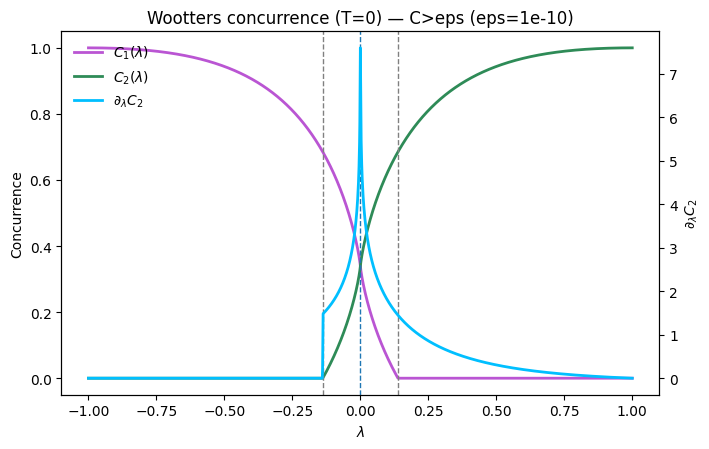

[T=0] mode=C_eps (C>eps (eps=1e-10))
    lambda_c1 (C1 -> 0) ~ 0.13899999976651373
    lambda_c2 (C2 turns on) ~ -0.13899999976651373


(<Figure size 720x460 with 2 Axes>,
 (<Axes: title={'center': 'Wootters concurrence (T=0) — C>eps (eps=1e-10)'}, xlabel='$\\lambda$', ylabel='Concurrence'>,
  <Axes: ylabel='$\\partial_\\lambda C_2$'>),
 (np.float64(0.13899999976651373), np.float64(-0.13899999976651373)))

In [41]:
make_figure_concurrence_vs_lambda(beta=np.inf, lamc_mode="C_eps", eps=1e-10)

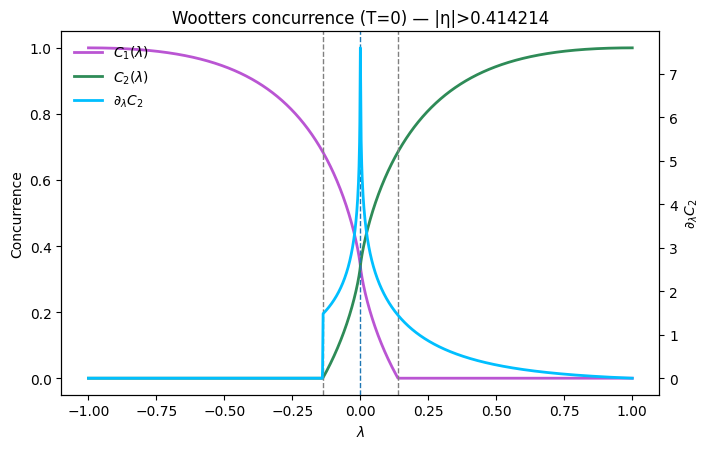

[T=0] mode=eta_threshold (|η|>0.414214)
    lambda_c1 (C1 -> 0) ~ 0.13829037981505563
    lambda_c2 (C2 turns on) ~ -0.1382903798150557


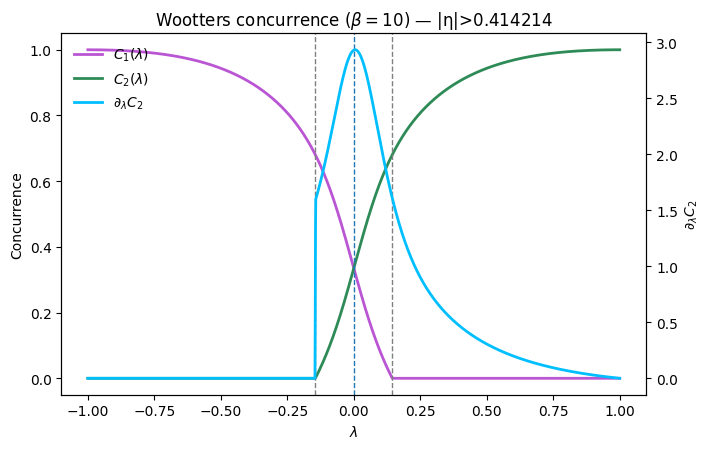

[$\beta=10$] mode=eta_threshold (|η|>0.414214)
    lambda_c1 (C1 -> 0) ~ 0.1446612652618132
    lambda_c2 (C2 turns on) ~ -0.14466126526181317


(<Figure size 720x460 with 2 Axes>,
 (<Axes: title={'center': 'Wootters concurrence ($\\beta=10$) — |η|>0.414214'}, xlabel='$\\lambda$', ylabel='Concurrence'>,
  <Axes: ylabel='$\\partial_\\lambda C_2$'>),
 (np.float64(0.1446612652618132), np.float64(-0.14466126526181317)))

In [42]:
make_figure_concurrence_vs_lambda(beta=np.inf, lamc_mode="eta_threshold")
make_figure_concurrence_vs_lambda(beta=10,     lamc_mode="eta_threshold")

In [43]:
import numpy as np
import matplotlib.pyplot as plt

ETA_CRIT_DEFAULT = np.sqrt(2.0) - 1.0  # ~0.41421356

def lambda_critical_for_beta(
    beta,
    lams,
    r,
    ks=KS,
    lamc_mode="C_eps",          # "C_eps" or "eta_threshold"
    eps=1e-10,                  # used if C_eps
    eta_crit=ETA_CRIT_DEFAULT,  # used if eta_threshold
):
    """
    For fixed beta, scan lambda grid and return the critical lambda boundary.
    r=0 -> C1: take RIGHT boundary (where C1 -> 0)
    r=1 -> C2: take LEFT boundary  (where C2 turns on)

    lamc_mode:
      - "C_eps":         boundary from C > eps
      - "eta_threshold": boundary from |eta| > eta_crit  (recommended)
    """
    eta = np.array([eta_continuum(l, beta=beta, r=r, ks=ks) for l in lams])

    if lamc_mode == "C_eps":
        y = np.array([concurrence_from_eta(x) for x in eta])
        thr = eps
    elif lamc_mode == "eta_threshold":
        y = np.abs(eta)
        thr = eta_crit
    else:
        raise ValueError('lamc_mode must be "C_eps" or "eta_threshold"')

    left, right = nonzero_region_boundaries(lams, y, eps=thr)
    return right if r == 0 else left


def make_figure_lambda_critical_vs_beta(
    betas=None,
    lam_min=-0.30,
    lam_max=0.30,
    nlam=3001,
    ks=KS,
    # --- NEW:
    lamc_mode="eta_threshold",      # default recommended
    eps=1e-10,
    eta_crit=ETA_CRIT_DEFAULT,
    print_values=True,
    save_csv_path=None,             # e.g. f"{FIG_DIR}/lambda_critical_vs_beta.csv"
    # ---
    savepath=None,
    show=True,
    title=None,
):
    if betas is None:
        betas = np.r_[np.geomspace(0.2, 30.0, 25), np.inf]

    lams = np.linspace(lam_min, lam_max, nlam)

    lamc1 = []
    lamc2 = []
    for beta in betas:
        lamc1.append(lambda_critical_for_beta(
            beta, lams, r=0, ks=ks,
            lamc_mode=lamc_mode, eps=eps, eta_crit=eta_crit
        ))
        lamc2.append(lambda_critical_for_beta(
            beta, lams, r=1, ks=ks,
            lamc_mode=lamc_mode, eps=eps, eta_crit=eta_crit
        ))

    lamc1 = np.array(lamc1, dtype=float)
    lamc2 = np.array(lamc2, dtype=float)

    # ---- PRINT TABLE
    if print_values:
        mode_str = f"C>eps (eps={eps:g})" if lamc_mode == "C_eps" else f"|η|>{eta_crit:.6f}"
        print("\nCritical lambdas: lambda_c(beta)")
        print(f"mode = {lamc_mode}  ({mode_str}), ks={ks}, lambda-grid=[{lam_min},{lam_max}] nlam={nlam}")
        print("--------------------------------------------------------------")
        print(f"{'beta':>10}   {'lambda_c1 (C1->0)':>18}   {'lambda_c2 (C2 on)':>18}")
        for b, c1, c2 in zip(betas, lamc1, lamc2):
            bstr  = "inf" if np.isinf(b) else f"{b:10.6g}"
            c1str = "None" if np.isnan(c1) else f"{c1:18.10f}"
            c2str = "None" if np.isnan(c2) else f"{c2:18.10f}"
            print(f"{bstr:>10}   {c1str}   {c2str}")

    # ---- SAVE CSV
    if save_csv_path is not None:
        beta_out = np.array(betas, dtype=float)
        header = "beta,lambda_c1,lambda_c2"
        data = np.column_stack([beta_out, lamc1, lamc2])
        np.savetxt(save_csv_path, data, delimiter=",", header=header, comments="")
        if print_values:
            print("\nSaved CSV to:", save_csv_path)

    # ---- Plot (log beta axis)
    finite = np.isfinite(betas)
    betas_f = np.array(betas)[finite]
    lamc1_f = lamc1[finite]
    lamc2_f = lamc2[finite]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(betas_f, lamc1_f, lw=2, label=r"$\lambda_{c1}(\beta)$  (C1$\to$0)")
    ax.plot(betas_f, lamc2_f, lw=2, label=r"$\lambda_{c2}(\beta)$  (C2 turns on)")

    # mark T=0 point (beta=inf) as a dot at the right edge
    if np.any(~finite):
        ax.scatter([betas_f.max()], [lamc1[~finite][0]], s=35)
        ax.scatter([betas_f.max()], [lamc2[~finite][0]], s=35)

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda_c$")
    mode_str = r"|η| threshold" if lamc_mode == "eta_threshold" else r"C>eps"
    ax.set_title(title or rf"Critical $\lambda_c(\beta)$ ({mode_str})")
    ax.legend(frameon=False)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax, (betas, lamc1, lamc2)


Critical lambdas: lambda_c(beta)
mode = eta_threshold  (|η|>0.414214), ks=[0.00000000e+00 7.66990394e-04 1.53398079e-03 ... 6.28088434e+00
 6.28165133e+00 6.28241832e+00], lambda-grid=[-0.3,0.3] nlam=200
--------------------------------------------------------------
      beta    lambda_c1 (C1->0)    lambda_c2 (C2 on)
       0.2   None   None
  0.246434   None   None
  0.303648   None   None
  0.374146   None   None
  0.461012   None   None
  0.568044   None   None
  0.699927   None   None
  0.862429        -0.1172628524         0.1172628524
   1.06266         0.0153992769        -0.0153992769
   1.30938         0.1024492696        -0.1024492696
   1.61337         0.1540892611        -0.1540892611
   1.98795         0.1797163780        -0.1797163780
   2.44949         0.1878438484        -0.1878438484
   3.01819         0.1856311556        -0.1856311556
   3.71892         0.1784166577        -0.1784166577
   4.58234         0.1696211150        -0.1696211150
   5.64622         0.161115

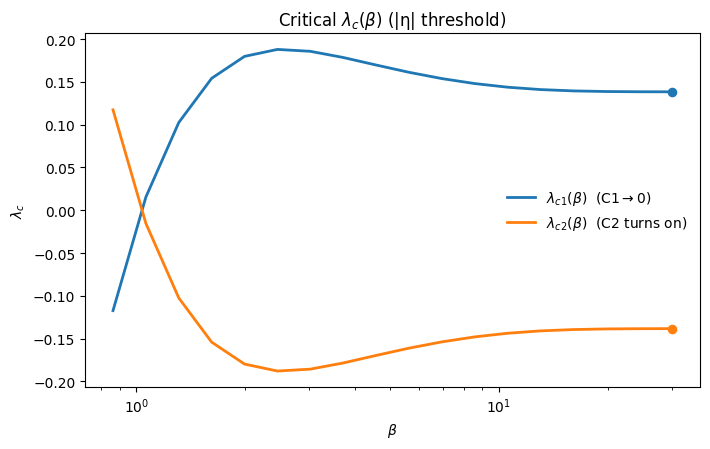

In [47]:
fig, ax, (betas, lamc1, lamc2) = make_figure_lambda_critical_vs_beta(
    lam_min=-0.3, lam_max=0.3, nlam=200,
    betas=np.r_[np.geomspace(0.2, 30.0, 25), np.inf],
    lamc_mode="eta_threshold",   # ✅ stabil
    ks=KS,
    savepath=f"{FIG_DIR}/fig_lambda_critical_vs_beta_eta.pdf",
    save_csv_path=f"{FIG_DIR}/lambda_critical_vs_beta_eta.csv",
    print_values=True,
    show=True,
)

In [48]:
import numpy as np
import matplotlib.pyplot as plt

ETA_BELL = 1/np.sqrt(2)          # ~0.70710678
BELL_CLASSICAL = 2.0

def average_bell_from_eta(eta):
    # using magnitude gives a clean physical criterion
    return 2*np.sqrt(2)*np.abs(eta)

def make_figure_average_bell_vs_lambda(
    betas=(np.inf, 30, 10, 5, 2, 1),
    lam_min=-1.0,
    lam_max=1.0,
    num=2001,
    r=0,
    ks=KS,
    savepath=None,
    show=True,
    title=None,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_avgBell_vs_lambda_r{r}.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for beta in betas:
        tag = r"$\beta=\infty$" if np.isinf(beta) else rf"$\beta={beta:g}$"
        eta = np.array([eta_continuum(l, beta=beta, r=r, ks=ks) for l in lams])
        B = average_bell_from_eta(eta)
        ax.plot(lams, B, lw=2, label=tag)

    ax.axhline(BELL_CLASSICAL, ls="--", lw=1)  # CHSH bound = 2

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\langle B\rangle$")
    ax.set_title(title or rf"Average Bell operator for pair r={r}")
    ax.legend(frameon=False, ncol=2)

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax


def make_figure_lambda_bell_critical_vs_beta(
    betas=None,
    lam_min=-1.0,
    lam_max=1.0,
    nlam=8001,
    r=0,
    ks=KS,
    savepath=None,
    show=True,
    print_values=True,
    title=None,
):
    if betas is None:
        betas = np.r_[np.geomspace(0.2, 30.0, 25), np.inf]

    lams = np.linspace(lam_min, lam_max, nlam)

    lamB = []
    for beta in betas:
        eta = np.array([eta_continuum(l, beta=beta, r=r, ks=ks) for l in lams])
        y = np.abs(eta)  # threshold will be ETA_BELL
        left, right = nonzero_region_boundaries(lams, y, eps=ETA_BELL)

        # choose boundary: for your conventions you can pick right (like C1)
        lamB.append(right)

    lamB = np.array(lamB, dtype=float)

    if print_values:
        print("\nBell-violation boundary lambda_B(beta) from |eta|>1/sqrt(2)")
        print(f"r={r}, ks={ks}, lambda-grid=[{lam_min},{lam_max}] nlam={nlam}")
        print("--------------------------------------------------------------")
        print(f"{'beta':>10}   {'lambda_B (right boundary)':>26}")
        for b, lb in zip(betas, lamB):
            bstr = "inf" if np.isinf(b) else f"{b:10.6g}"
            lbstr = "None" if np.isnan(lb) else f"{lb:26.10f}"
            print(f"{bstr:>10}   {lbstr}")

    # plot vs beta (log axis)
    finite = np.isfinite(betas)
    betas_f = np.array(betas)[finite]
    lamB_f = lamB[finite]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(betas_f, lamB_f, lw=2, label=rf"$\lambda_B(\beta)$  (|η|>{ETA_BELL:.3f})")

    if np.any(~finite):
        ax.scatter([betas_f.max()], [lamB[~finite][0]], s=35)

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda_B$")
    ax.set_title(title or r"Bell-violation boundary from average Bell operator")
    ax.legend(frameon=False)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax, (betas, lamB)

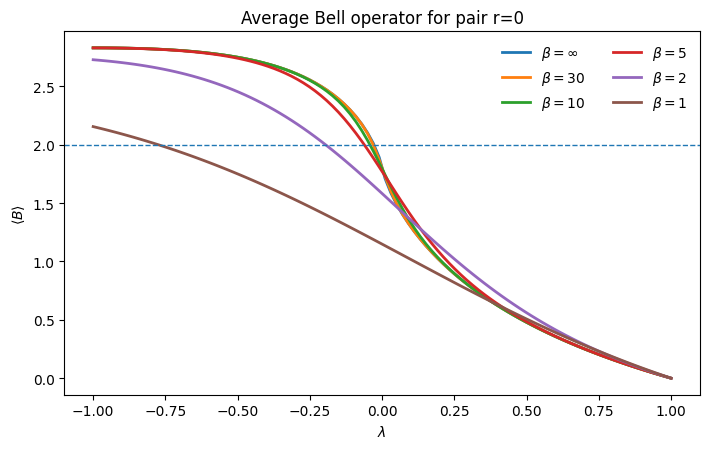

(<Figure size 720x460 with 1 Axes>,
 <Axes: title={'center': 'Average Bell operator for pair r=0'}, xlabel='$\\lambda$', ylabel='$\\langle B\\rangle$'>)

In [50]:
make_figure_average_bell_vs_lambda(
    betas=(np.inf, 30, 10, 5, 2, 1),
    lam_min=-1, lam_max=1, num=100,
    r=0, ks=KS,
    savepath=f"{FIG_DIR}/fig_avgBell_vs_lambda_r0.pdf",
)

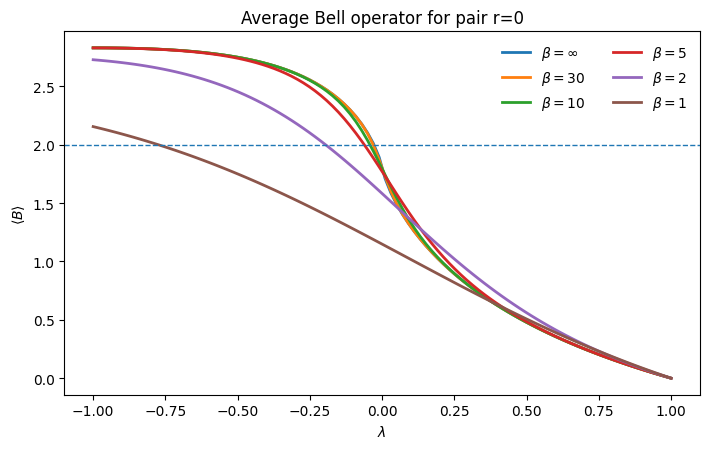

(<Figure size 720x460 with 1 Axes>,
 <Axes: title={'center': 'Average Bell operator for pair r=0'}, xlabel='$\\lambda$', ylabel='$\\langle B\\rangle$'>)

In [52]:
make_figure_average_bell_vs_lambda(
    betas=(np.inf, 30, 10, 5, 2, 1),
    lam_min=-1, lam_max=1, num=100,
    r=0, ks=KS,
    savepath=f"{FIG_DIR}/fig_avgBell_vs_lambda_r0.pdf",
)

In [58]:
ETA_BELL = 1/np.sqrt(2)

def lambda_bell_critical_for_beta(beta, lams, r, ks=KS, eta_crit=ETA_BELL):
    eta = np.array([
        eta_continuum(l, beta=beta, r=r, ks=ks)
        for l in lams
    ])

    y = np.abs(eta)

    left, right = nonzero_region_boundaries(
        lams,
        y,
        eps=eta_crit
    )

    # same convention as concurrence
    return right if r == 0 else left


def make_figure_lambda_bell_critical_vs_beta(
    betas=None,
    lam_min=-1.0,
    lam_max=1.0,
    nlam=8001,
    ks=KS,
    savepath=None,
    show=True,
    print_values=True,
):
    """
    Bell phase diagram:
        lambda_B1(beta)  (r=0)
        lambda_B2(beta)  (r=1)
    """

    if betas is None:
        betas = np.r_[np.geomspace(0.2, 30.0, 30), np.inf]

    lams = np.linspace(lam_min, lam_max, nlam)

    lamB1 = []
    lamB2 = []

    for beta in betas:

        lamB1.append(
            lambda_bell_critical_for_beta(
                beta, lams, r=0, ks=ks
            )
        )

        lamB2.append(
            lambda_bell_critical_for_beta(
                beta, lams, r=1, ks=ks
            )
        )

    lamB1 = np.array(lamB1, dtype=float)
    lamB2 = np.array(lamB2, dtype=float)

    # ---- PRINT TABLE

    if print_values:

        print("\nBell phase boundaries:")
        print("-------------------------------------------------------")
        print(f"{'beta':>10}   {'lambda_B1':>12}   {'lambda_B2':>12}")

        for b, lb1, lb2 in zip(betas, lamB1, lamB2):

            bstr = "inf" if np.isinf(b) else f"{b:10.5g}"

            s1 = "None" if np.isnan(lb1) else f"{lb1:12.6f}"
            s2 = "None" if np.isnan(lb2) else f"{lb2:12.6f}"

            print(f"{bstr:>10}   {s1}   {s2}")

    # ---- Plot

    finite = np.isfinite(betas)

    betas_f = np.array(betas)[finite]

    lamB1_f = lamB1[finite]
    lamB2_f = lamB2[finite]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    ax.plot(
        betas_f,
        lamB1_f,
        lw=2,
        label=r"$\lambda_{B1}(\beta)$  (r=0)"
    )

    ax.plot(
        betas_f,
        lamB2_f,
        lw=2,
        label=r"$\lambda_{B2}(\beta)$  (r=1)"
    )

    # ground state markers
    if np.any(~finite):

        ax.scatter([betas_f.max()], [lamB1[~finite][0]], s=35)
        ax.scatter([betas_f.max()], [lamB2[~finite][0]], s=35)

    ax.set_xscale("log")

    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda_B$")

    ax.set_title(
        r"Bell violation phase diagram ($|\eta|>1/\sqrt{2}$)"
    )

    ax.legend(frameon=False)

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax, (betas, lamB1, lamB2)


Bell phase boundaries:
-------------------------------------------------------
      beta      lambda_B1      lambda_B2
       0.2   None   None
   0.23772   None   None
   0.28256   None   None
   0.33585   None   None
   0.39919   None   None
   0.47448   None   None
   0.56397   None   None
   0.67034   None   None
   0.79677   None   None
   0.94704      -0.865850       0.865850
    1.1257      -0.610613       0.610613
     1.338      -0.429934       0.429934
    1.5903      -0.304034       0.304034
    1.8902      -0.217903       0.217903
    2.2468      -0.160095       0.160095
    2.6705      -0.121787       0.121787
    3.1742      -0.096439       0.096439
    3.7729      -0.079479       0.079479
    4.4844      -0.067727       0.067727
    5.3302      -0.059411       0.059411
    6.3355      -0.053123       0.053123
    7.5304      -0.048314       0.048314
    8.9507      -0.044602       0.044602
    10.639      -0.041588       0.041588
    12.645      -0.039091       0.03909

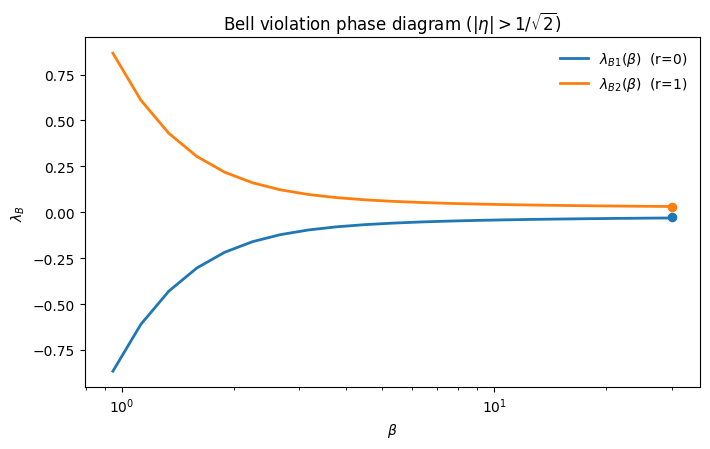

(<Figure size 720x460 with 1 Axes>,
 <Axes: title={'center': 'Bell violation phase diagram ($|\\eta|>1/\\sqrt{2}$)'}, xlabel='$\\beta$', ylabel='$\\lambda_B$'>,
 (array([ 0.2       ,  0.23772104,  0.28255647,  0.33584809,  0.39919079,
          0.47448025,  0.5639697 ,  0.67033733,  0.79676644,  0.94704074,
          1.12565756,  1.33796244,  1.59030913,  1.89024971,  2.24676066,
          2.67051142,  3.17418379,  3.77285139,  4.48443082,  5.33021784,
          6.3355247 ,  7.53043766,  8.95071744, 10.63886938, 12.64541558,
         15.03040684, 17.86521988, 21.23469344, 25.23966725, 30.        ,
                 inf]),
  array([        nan,         nan,         nan,         nan,         nan,
                 nan,         nan,         nan,         nan, -0.86584964,
         -0.61061253, -0.42993363, -0.3040344 , -0.21790258, -0.16009502,
         -0.12178653, -0.09643894, -0.07947863, -0.06772732, -0.05941126,
         -0.05312291, -0.0483143 , -0.04460245, -0.04158764, -0.03909124,
 

In [60]:
make_figure_lambda_bell_critical_vs_beta(
    betas=np.r_[np.geomspace(0.2, 30.0, 30), np.inf],
    lam_min=-1,
    lam_max=1,
    nlam=100,
    ks=KS,
    savepath=f"{FIG_DIR}/fig_lambda_bell_critical_vs_beta.pdf",
)

In [61]:
import numpy as np
import matplotlib.pyplot as plt

ETA_CONC = np.sqrt(2.0) - 1.0   # concurrence threshold in |eta|
ETA_BELL = 1/np.sqrt(2.0)       # Bell violation threshold in |eta|

def lambda_boundary_from_eta_threshold(beta, lams, ks=KS, r=0, eta_crit=ETA_CONC):
    """
    Generic boundary for fixed beta from |eta(lam,beta)| > eta_crit.
    For r=0 we follow the same convention as before: take RIGHT boundary.
    """
    eta = np.array([eta_continuum(l, beta=beta, r=r, ks=ks) for l in lams])
    y = np.abs(eta)
    left, right = nonzero_region_boundaries(lams, y, eps=eta_crit)
    return right  # r=0 convention

def make_figure_lambda_critical_overlay_conc_vs_bell_r0(
    betas=None,
    lam_min=-1.0,
    lam_max=1.0,
    nlam=8001,
    ks=KS,
    savepath=None,
    show=True,
    print_values=True,
):
    if betas is None:
        betas = np.r_[np.geomspace(0.2, 30.0, 30), np.inf]

    lams = np.linspace(lam_min, lam_max, nlam)

    lam_conc = []
    lam_bell = []
    for beta in betas:
        lam_conc.append(lambda_boundary_from_eta_threshold(beta, lams, ks=ks, r=0, eta_crit=ETA_CONC))
        lam_bell.append(lambda_boundary_from_eta_threshold(beta, lams, ks=ks, r=0, eta_crit=ETA_BELL))

    lam_conc = np.array(lam_conc, dtype=float)
    lam_bell = np.array(lam_bell, dtype=float)

    if print_values:
        print("\nOverlay boundaries (r=0): concurrence vs Bell")
        print("-------------------------------------------------------------")
        print(f"{'beta':>10}   {'lambda_c1':>12}   {'lambda_B1':>12}")
        for b, lc, lb in zip(betas, lam_conc, lam_bell):
            bstr = "inf" if np.isinf(b) else f"{b:10.6g}"
            lcstr = "None" if np.isnan(lc) else f"{lc:12.6f}"
            lbstr = "None" if np.isnan(lb) else f"{lb:12.6f}"
            print(f"{bstr:>10}   {lcstr}   {lbstr}")

    # plot (log beta axis)
    finite = np.isfinite(betas)
    betas_f = np.array(betas)[finite]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    ax.plot(betas_f, lam_conc[finite], lw=2, label=r"$\lambda_{c1}(\beta)$ (concurrence, r=0)")
    ax.plot(betas_f, lam_bell[finite], lw=2, label=r"$\lambda_{B1}(\beta)$ (Bell, r=0)")

    # mark beta=inf as dots at right edge
    if np.any(~finite):
        ax.scatter([betas_f.max()], [lam_conc[~finite][0]], s=35)
        ax.scatter([betas_f.max()], [lam_bell[~finite][0]], s=35)

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda$")
    ax.set_title(r"Phase boundaries (r=0): concurrence vs Bell violation")
    ax.legend(frameon=False)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax, (betas, lam_conc, lam_bell)


Overlay boundaries (r=0): concurrence vs Bell
-------------------------------------------------------------
      beta      lambda_c1      lambda_B1
       0.2   None   None
  0.237721   None   None
  0.282556   None   None
  0.335848   None   None
  0.399191   None   None
   0.47448   None   None
   0.56397   None   None
  0.670337   None   None
  0.796766      -0.181824   None
  0.947041      -0.051459   None
   1.12566       0.043519   None
   1.33796       0.109267   None
   1.59031       0.151466   None
   1.89025       0.175437      -0.217848
   2.24676       0.186107      -0.160027
   2.67051       0.187833      -0.121712
   3.17418       0.184189      -0.096374
   3.77285       0.177832      -0.079390
   4.48443       0.170538      -0.067678
   5.33022       0.163371      -0.059297
   6.33552       0.156894      -0.053060
   7.53044       0.151380      -0.048261
   8.95072       0.146940      -0.044457
   10.6389       0.143581      -0.041374
   12.6454       0.141238      -0.

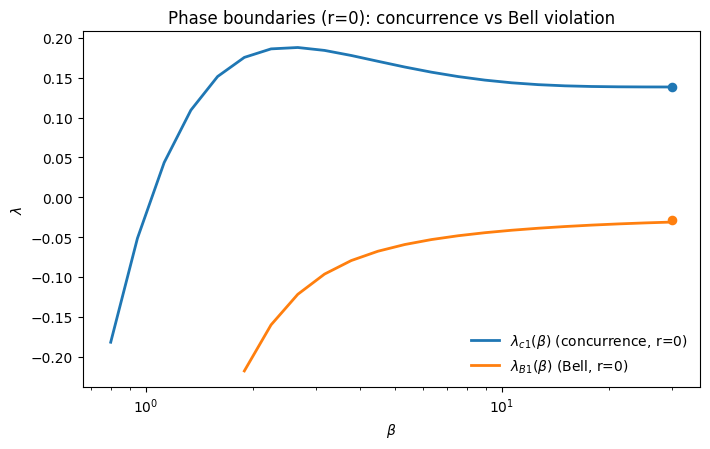

(<Figure size 720x460 with 1 Axes>,
 <Axes: title={'center': 'Phase boundaries (r=0): concurrence vs Bell violation'}, xlabel='$\\beta$', ylabel='$\\lambda$'>,
 (array([ 0.2       ,  0.23772104,  0.28255647,  0.33584809,  0.39919079,
          0.47448025,  0.5639697 ,  0.67033733,  0.79676644,  0.94704074,
          1.12565756,  1.33796244,  1.59030913,  1.89024971,  2.24676066,
          2.67051142,  3.17418379,  3.77285139,  4.48443082,  5.33021784,
          6.3355247 ,  7.53043766,  8.95071744, 10.63886938, 12.64541558,
         15.03040684, 17.86521988, 21.23469344, 25.23966725, 30.        ,
                 inf]),
  array([        nan,         nan,         nan,         nan,         nan,
                 nan,         nan,         nan, -0.1818237 , -0.05145948,
          0.04351856,  0.10926715,  0.1514663 ,  0.17543728,  0.18610684,
          0.18783281,  0.18418851,  0.1778323 ,  0.17053813,  0.16337114,
          0.15689406,  0.15138003,  0.1469397 ,  0.14358131,  0.14123801,
  

In [67]:
make_figure_lambda_critical_overlay_conc_vs_bell_r0(
    betas=np.r_[np.geomspace(0.2, 30.0, 30), np.inf],
    lam_min=-0.3, lam_max=0.3, nlam=200,
    ks=KS,
    savepath=f"{FIG_DIR}/fig_overlay_lambda_c_vs_lambda_B_r0.pdf",
    show=True,
    print_values=True,
)

In [71]:
def make_figure_lambda_phase_regions_conc_vs_bell_r0(
    betas=None,
    lam_min=-1.0,
    lam_max=1.0,
    nlam=200,
    ks=KS,
    savepath=None,
    show=True,
):
    if betas is None:
        betas = np.r_[np.geomspace(0.2, 30.0, 400), np.inf]

    lams = np.linspace(lam_min, lam_max, nlam)

    lam_conc = []
    lam_bell = []

    for beta in betas:

        lam_conc.append(
            lambda_boundary_from_eta_threshold(
                beta, lams, ks=ks, r=0,
                eta_crit=np.sqrt(2)-1
            )
        )

        lam_bell.append(
            lambda_boundary_from_eta_threshold(
                beta, lams, ks=ks, r=0,
                eta_crit=1/np.sqrt(2)
            )
        )

    lam_conc = np.array(lam_conc, float)
    lam_bell = np.array(lam_bell, float)

    finite = np.isfinite(betas)

    betas_f = np.array(betas)[finite]
    lam_conc_f = lam_conc[finite]
    lam_bell_f = lam_bell[finite]

    fig, ax = plt.subplots(figsize=(7.2,4.8))

    # ---- region shading

    ax.fill_betweenx(
        betas_f,
        lam_min,
        lam_bell_f,
        color="lightblue",
        alpha=0.5,
        label="Bell-violating region"
    )

    ax.fill_betweenx(
        betas_f,
        lam_bell_f,
        lam_conc_f,
        color="khaki",
        alpha=0.6,
        label="Entangled (Bell-local)"
    )

    ax.fill_betweenx(
        betas_f,
        lam_conc_f,
        lam_max,
        color="lightgray",
        alpha=0.5,
        label="Separable region"
    )

    # ---- boundary curves

    ax.plot(
        lam_conc_f,
        betas_f,
        color="red",
        lw=2,
        label=r"$\lambda_{c1}(\beta)$"
    )

    ax.plot(
        lam_bell_f,
        betas_f,
        color="blue",
        lw=2,
        label=r"$\lambda_{B1}(\beta)$"
    )

    ax.set_yscale("log")

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")

    ax.set_xlim(lam_min, lam_max)

    ax.set_title(
        r"Phase diagram from concurrence and Bell violation (r=0)"
    )

    ax.legend(frameon=False, loc="upper right")

    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

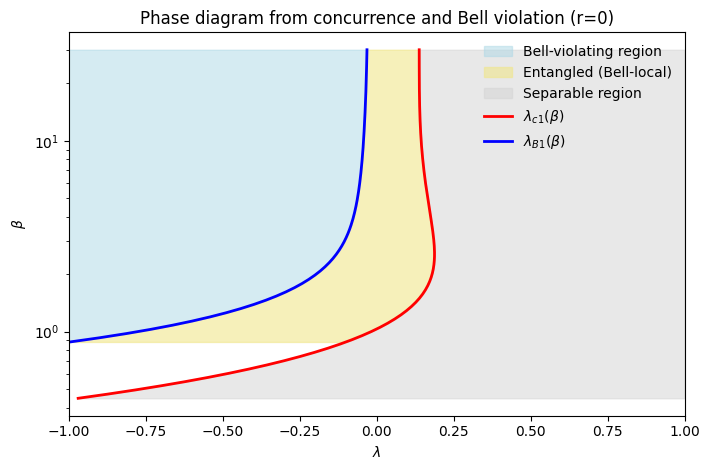

(<Figure size 720x480 with 1 Axes>,
 <Axes: title={'center': 'Phase diagram from concurrence and Bell violation (r=0)'}, xlabel='$\\lambda$', ylabel='$\\beta$'>)

In [73]:
make_figure_lambda_phase_regions_conc_vs_bell_r0(
    betas=np.geomspace(0.2,30,200),
    lam_min=-1,
    lam_max=1,
    savepath=f"{FIG_DIR}/fig_phase_regions_conc_vs_bell_r0.pdf"
)

In [78]:
def make_figure_lambda_phase_regions_conc_vs_bell_r0(
    betas=None,
    lam_min=-1.0,
    lam_max=1.0,
    nlam=200,
    ks=KS,
    savepath=None,
    show=True,
):

    if betas is None:
        betas = np.geomspace(0.2, 30.0, 400)

    lams = np.linspace(lam_min, lam_max, nlam)

    lam_conc = np.array([
        lambda_boundary_from_eta_threshold(
            beta, lams, ks=ks, r=0,
            eta_crit=np.sqrt(2)-1
        )
        for beta in betas
    ], dtype=float)

    lam_bell = np.array([
        lambda_boundary_from_eta_threshold(
            beta, lams, ks=ks, r=0,
            eta_crit=1/np.sqrt(2)
        )
        for beta in betas
    ], dtype=float)

    # ---- remove NaN safely

    valid = np.isfinite(lam_conc) & np.isfinite(lam_bell)

    betas_f = betas[valid]
    lam_conc_f = lam_conc[valid]
    lam_bell_f = lam_bell[valid]

    fig, ax = plt.subplots(figsize=(7.2,4.8))

    # ---- region shading (correct order)

    ax.fill_betweenx(
        betas_f,
        lam_min,
        lam_bell_f,
        color="lightblue",
        alpha=0.5,
        zorder=0
    )

    ax.fill_betweenx(
        betas_f,
        lam_bell_f,
        lam_conc_f,
        color="khaki",
        alpha=0.6,
        zorder=0
    )

    ax.fill_betweenx(
        betas_f,
        lam_conc_f,
        lam_max,
        color="lightgray",
        alpha=0.5,
        zorder=0
    )

    # ---- boundary curves

    ax.plot(
        lam_conc_f,
        betas_f,
        color="red",
        lw=2,
        label=r"$\lambda_{c1}(\beta)$",
        zorder=3
    )

    ax.plot(
        lam_bell_f,
        betas_f,
        color="blue",
        lw=2,
        label=r"$\lambda_{B1}(\beta)$",
        zorder=3
    )

    # ---- axis control (remove white gaps)

    ax.set_xlim(lam_min, lam_max)
    ax.set_ylim(betas_f.min(), betas_f.max())

    ax.set_yscale("log")

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")

    ax.set_title(
        r"Phase diagram from concurrence and Bell violation (r=0)"
    )

    ax.legend(frameon=False, loc="upper right")

    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

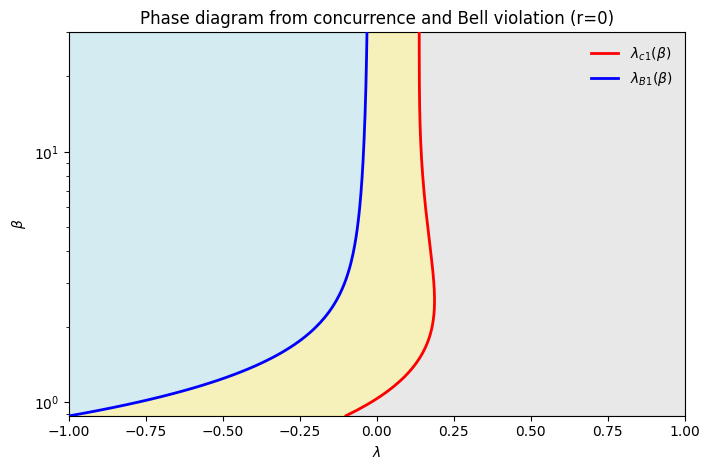

(<Figure size 720x480 with 1 Axes>,
 <Axes: title={'center': 'Phase diagram from concurrence and Bell violation (r=0)'}, xlabel='$\\lambda$', ylabel='$\\beta$'>)

In [79]:
make_figure_lambda_phase_regions_conc_vs_bell_r0(
    betas=np.geomspace(0.2,30,200),
    lam_min=-1,
    lam_max=1,
    savepath=f"{FIG_DIR}/fig_phase_regions_conc_vs_bell_r0.pdf"
)

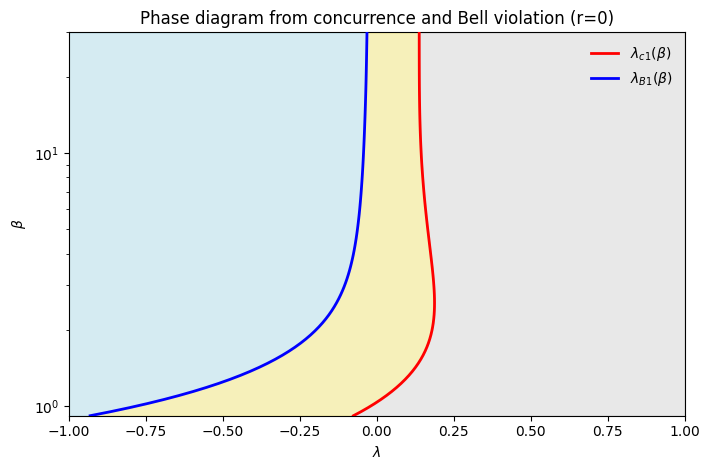

(<Figure size 720x480 with 1 Axes>,
 <Axes: title={'center': 'Phase diagram from concurrence and Bell violation (r=0)'}, xlabel='$\\lambda$', ylabel='$\\beta$'>)

In [80]:
make_figure_lambda_phase_regions_conc_vs_bell_r0(
    betas=np.geomspace(0.02,30,200),
    lam_min=-1,
    lam_max=1,
    savepath=f"{FIG_DIR}/fig_phase_regions_conc_vs_bell_r0.pdf"
)